# 04 · Modelado

**Fase CRISP-DM:** modelado.

**Objetivo.** Comparar técnicas de estimación del número esperado de consultas por zona, de simple a complejo, con
validación cruzada espacial por bloques, y elegir una con una regla declarada antes de ver los resultados. Este
notebook **solo usa entrenamiento**: la lista de bloques de prueba sirve únicamente para descartarlos.

| | |
|---|---|
| **Entradas** | `data/processed/tabla_modelado.parquet`, `resultados/03_feature_engineering/test_blocks.csv` |
| **Salidas** | `resultados/04_modelado/`: métricas por pliegue, resumen, predicciones fuera de pliegue, regla de selección, coeficientes, `modelo_final.joblib`, figuras y `metricas.json` |

## 1. Configuración

In [1]:
import sys
from pathlib import Path

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(RAIZ))

In [2]:
from src.entorno import *  # noqa: F403
from src import modelos as mo

import joblib

FASE = "04_modelado"
limpiar_salidas(FASE)
M = {}
tiempo = cronometro()

## 2. Datos de entrenamiento
**Tipo de datos:** tabulares por zona (conteos, población, predictores y bloque).

Se toman las zonas del modelo y se descartan las de los bloques de prueba leyendo `test_blocks.csv`. Se verifica que
no queda ninguna zona de prueba.

In [3]:
tabla = pl.read_parquet(config.TABLA_MODELADO).filter(pl.col("in_model"))
bloques_prueba = pl.read_csv(config.RESULTADOS / "03_feature_engineering" / "test_blocks.csv")["block_id"]
entreno = tabla.filter(~pl.col("block_id").is_in(bloques_prueba.implode())).to_pandas()
assert not entreno["in_test"].any(), "Hay zonas de prueba en el entrenamiento"
assert len(entreno) == leer_metricas("03_feature_engineering")["zonas_modelo"] - leer_metricas("03_feature_engineering")["zonas_prueba"]
M.update({"zonas_entrenamiento": len(entreno), "bloques_entrenamiento": entreno["block_id"].nunique()})
print(f"{len(entreno):,} zonas en {M['bloques_entrenamiento']} bloques de entrenamiento")

1,029 zonas en 41 bloques de entrenamiento


## 3. Protocolo (declarado antes de modelar)

El protocolo está fijado en `config.py` y se commiteó antes de ejecutar este notebook.

| Elemento | Decisión |
|---|---|
| Objetivo | `query_count`: consultas de la zona en todo el período |
| Exposición | `population` como offset: todas las técnicas estiman una tasa por habitante × población |
| Predictores | `config.PREDICTORES` (`dist_centro_km`, `log(1 + pop_ring1)`); las variables GTFS nunca entran |
| Validación | `GroupKFold(PLIEGUES)` por `block_id`: cada bloque H3 res 6 cae entero en un pliegue |
| Métrica principal | devianza de Poisson media en validación (adecuada para conteos) |
| Métricas de apoyo | D² frente a la media, MAE, calibración (esperado / observado) y Spearman |
| Regla de selección | la técnica **más simple** cuya devianza media no supera la mejor + `TOLERANCIA_EE` errores estándar |

Escalera de técnicas, de simple a complejo (cada peldaño debe ganarse su complejidad):

| Código | Técnica | Qué supone |
|---|---|---|
| B0 | tasa global × población | las consultas son proporcionales a la población |
| B1 | tasa por municipio × población | heterogeneidad administrativa |
| B2 | tasa por anillo × población | gradiente centro-periferia |
| B3 | tasa de las zonas vecinas de entrenamiento × población | dependencia espacial local |
| M1 | regresión de Poisson con offset | tasa log-lineal en distancia y población vecina |
| M2 | binomial negativa NB2 con offset | M1 más sobredispersión |
| M3 | gradient boosting con pérdida de Poisson | no linealidad e interacciones (hiperparámetros por validación anidada) |

## 4. Validación cruzada espacial
**Tipo de datos:** numéricos (métricas por pliegue).

Cada técnica se ajusta en 4 pliegues y predice el quinto, cinco veces. Todo lo que se estima (tasas, coeficientes,
alfa, hiperparámetros) se estima dentro del pliegue de entrenamiento, así que no hay fuga. Es la celda más lenta
porque M3 busca sus hiperparámetros dentro de cada pliegue.

In [4]:
por_pliegue, oof = mo.validar_por_bloques(entreno, mo.ESCALERA)
guardar_tabla(por_pliegue.round(4), "cv_por_pliegue", FASE)
guardar_tabla(oof.sort_values(["tecnica", "h3_cell"]), "predicciones_oof", FASE)
tiempo("validación cruzada")

⏱ validación cruzada: 97.9 s (acumulado 98 s)


Resumen por técnica: media y desviación estándar entre pliegues de cada métrica, y las métricas de todas las
predicciones fuera de pliegue juntas (la calibración conjunta es más estable que la media de los pliegues, porque un
pliegue sin el centro de la ciudad tiene muy pocas consultas).

In [5]:
resumen = por_pliegue.groupby("tecnica")[["devianza_poisson", "d2", "mae", "spearman"]].agg(["mean", "std"])
resumen.columns = [f"{m}_{e}".replace("_mean", "_media").replace("_std", "_de") for m, e in resumen.columns]
conjunto = oof.groupby("tecnica").apply(lambda d: pd.Series(mo.metricas(d["observado"], d["esperado"])), include_groups=False)
resumen = resumen.join(conjunto.add_prefix("oof_")).reindex(mo.ESCALERA).reset_index()
guardar_tabla(resumen.round(4), "cv_resumen", FASE)
resumen[["tecnica", "devianza_poisson_media", "devianza_poisson_de", "d2_media", "oof_calibracion", "oof_spearman"]].round(3)

,tecnica,devianza_poisson_media,devianza_poisson_de,d2_media,oof_calibracion,oof_spearman
0,B0,5676.071,6645.781,-2.000,0.922,0.800
1,B1,5665.345,5577.026,-1.572,0.879,0.663
2,B2,4742.668,5579.275,-1.496,0.903,0.773
3,B3,1389.295,1944.054,0.730,0.977,0.802
4,M1,994.584,1172.288,0.726,0.807,0.760
5,M2,4190.066,7098.752,0.457,0.354,0.834
6,M3,2265.885,4200.099,0.733,0.641,0.832


## 5. Sobredispersión
**Tipo de datos:** numéricos (dispersión de un modelo de conteo).

Si la varianza fuera igual a la media (supuesto de Poisson), la dispersión de Pearson del M1 valdría cerca de 1. El
alfa de la binomial negativa mide cuánto crece la varianza por encima de la media.

In [6]:
m1, m2 = mo.M1().fit(entreno), mo.M2().fit(entreno)
M.update({"dispersion_pearson_m1": round(mo.dispersion_pearson(m1, entreno), 1), "alfa_nb2": round(m2.alfa_, 3)})
coef = pd.DataFrame({"M1_poisson": m1.resultado_.params, "M2_binomial_negativa": m2.resultado_.params}).round(4)
guardar_tabla(coef.reset_index(names="parametro"), "coeficientes", FASE)
print({k: M[k] for k in ("dispersion_pearson_m1", "alfa_nb2")})

{'dispersion_pearson_m1': 62143817.5, 'alfa_nb2': 2.63}


## 6. Comparación de técnicas
**Tipo de datos:** numéricos (devianza por técnica).

Barras: devianza media de validación; líneas: ± 1 error estándar entre pliegues. La línea discontinua marca el umbral
de la regla (mejor media + 1 EE).

PosixPath('/home/robvox/Desktop/trufi-data-science/resultados/04_modelado/figuras/comparacion_tecnicas.png')

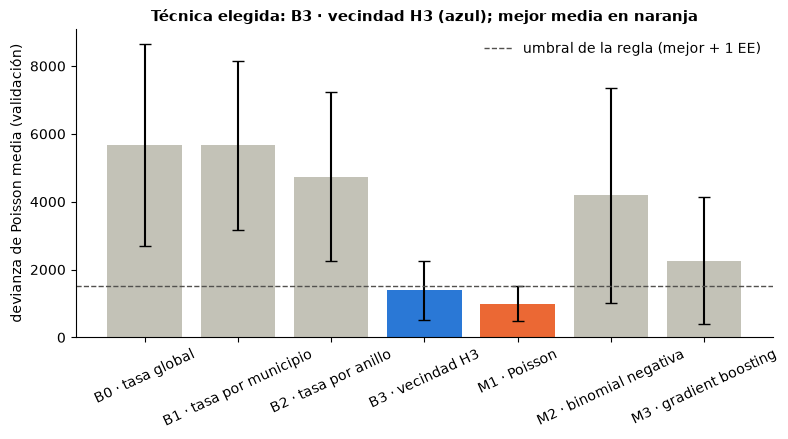

In [7]:
elegida, regla = mo.regla_seleccion(por_pliegue)
guardar_tabla(regla.round(4), "regla_seleccion", FASE)
fig, ax = plt.subplots(figsize=(9, 4))
colores = [AZUL if e else (NARANJA if b else GRIS) for e, b in zip(regla["elegida"], regla["mejor"], strict=True)]
ax.bar([mo.NOMBRE[t] for t in regla["tecnica"]], regla["devianza_media"], yerr=regla["ee"], color=colores, capsize=4)
ax.axhline(regla["umbral"].iloc[0], color=TINTA, ls="--", lw=1, label="umbral de la regla (mejor + 1 EE)")
ax.set(ylabel="devianza de Poisson media (validación)", title=f"Técnica elegida: {mo.NOMBRE[elegida]} (azul); mejor media en naranja")
ax.tick_params(axis="x", rotation=25)
ax.legend(frameon=False)
guardar_figura(fig, "comparacion_tecnicas", FASE)

Calibración fuera de pliegue de la técnica elegida frente a la mejor en media: cada punto es una zona de entrenamiento
predicha sin verse a sí misma ni a su bloque. Sobre la diagonal, lo esperado coincide con lo observado.

PosixPath('/home/robvox/Desktop/trufi-data-science/resultados/04_modelado/figuras/calibracion_oof.png')

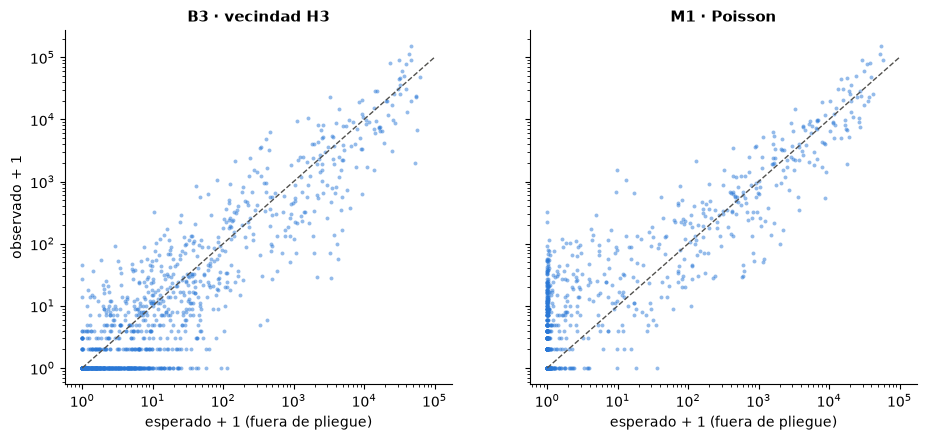

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
for ax, t in zip(axes, [elegida, regla.loc[regla["mejor"], "tecnica"].item()], strict=True):
    d = oof[oof["tecnica"] == t]
    ax.scatter(d["esperado"] + 1, d["observado"] + 1, s=8, alpha=0.5, color=AZUL, lw=0)
    ax.plot([1, 1e5], [1, 1e5], color=TINTA, ls="--", lw=1)
    ax.set(xscale="log", yscale="log", xlabel="esperado + 1 (fuera de pliegue)", title=mo.NOMBRE[t])
axes[0].set_ylabel("observado + 1")
guardar_figura(fig, "calibracion_oof", FASE)

## 7. Regla de selección
Se aplica la regla declarada, sin ajustarla después de ver los resultados.

In [9]:
fila = regla.set_index("tecnica")
M.update({"tecnica_elegida": elegida, "tecnica_mejor_media": fila.index[fila["mejor"]].item(),
          "umbral_regla": round(float(fila["umbral"].iloc[0]), 3)})
for t in mo.ESCALERA:
    M[f"cv_devianza_{t}"] = round(float(fila.loc[t, "devianza_media"]), 3)
    M[f"cv_devianza_de_{t}"] = round(float(fila.loc[t, "devianza_de"]), 3)
print(f"Elegida: {mo.NOMBRE[elegida]} | mejor en media: {mo.NOMBRE[M['tecnica_mejor_media']]} | umbral {M['umbral_regla']}")
regla[["tecnica", "devianza_media", "ee", "dentro_de_1ee", "mejor", "elegida"]].round(2)

Elegida: B3 · vecindad H3 | mejor en media: M1 · Poisson | umbral 1518.847


,tecnica,devianza_media,ee,dentro_de_1ee,mejor,elegida
0,B0,5676.07,2972.08,False,False,False
1,B1,5665.34,2494.12,False,False,False
2,B2,4742.67,2495.13,False,False,False
3,B3,1389.29,869.41,True,False,True
4,M1,994.58,524.26,True,True,False
5,M2,4190.07,3174.66,False,False,False
6,M3,2265.89,1878.34,False,False,False


## 8. Ajuste final
La técnica elegida se ajusta con **todo** el entrenamiento y se guarda. La evaluación la aplicará una sola vez a la
prueba reservada.

In [10]:
final = mo.crear(elegida).fit(entreno)
joblib.dump(final, config.RESULTADOS / FASE / "modelo_final.joblib")
r = resumen.set_index("tecnica").loc[elegida]
M.update({"cv_d2_elegida": round(float(r["d2_media"]), 3), "cv_d2_de_elegida": round(float(r["d2_de"]), 3),
          "cv_spearman_elegida": round(float(r["spearman_media"]), 3),
          "oof_calibracion_elegida": round(float(r["oof_calibracion"]), 3)})
tiempo("ajuste final")
print(f"modelo_final.joblib: {type(final).__name__}")

⏱ ajuste final: 6.1 s (acumulado 104 s)
modelo_final.joblib: B3


## 9. Verificaciones

### 9.1 Sin zonas de prueba
Ninguna zona ni bloque de prueba aparece en las predicciones fuera de pliegue.

In [11]:
assert not set(oof["h3_cell"]) & set(tabla.filter(pl.col("in_test"))["h3_cell"]), "Zonas de prueba en la validación"
print("Validación solo con entrenamiento")

Validación solo con entrenamiento


### 9.2 Pliegues por bloque
Cada zona de entrenamiento se predice exactamente una vez por técnica, y ningún bloque se reparte entre pliegues.

In [12]:
assert (oof.groupby("tecnica").size() == len(entreno)).all()
pliegue_de_bloque = oof.merge(entreno[["h3_cell", "block_id"]], on="h3_cell").groupby("block_id")["pliegue"].nunique()
assert (pliegue_de_bloque == 1).all(), "Un bloque quedó repartido entre pliegues"
print(f"{len(entreno):,} zonas predichas una vez por técnica; {len(pliegue_de_bloque)} bloques enteros")

1,029 zonas predichas una vez por técnica; 41 bloques enteros


### 9.3 GTFS fuera del modelo
Los predictores efectivos no incluyen ninguna variable de contraste.

In [13]:
assert set(mo.disenio(entreno).columns) == set(config.PREDICTORES)
assert not set(config.PREDICTORES) & set(config.CONTRASTE)
print("Predictores:", list(mo.disenio(entreno).columns))

Predictores: ['dist_centro_km', 'pop_ring1']


## 10. Cierre

In [14]:
M.update({"pliegues": config.PLIEGUES, "tolerancia_ee": config.TOLERANCIA_EE, "semilla": config.SEMILLA})
ruta = guardar_metricas(FASE, M)
tiempo("cierre")
print(f"{len(M)} métricas → {ruta.relative_to(config.RAIZ)}")

⏱ cierre: 0.1 s (acumulado 104 s)
28 métricas → resultados/04_modelado/metricas.json
